# Mexico Real Estate Price Analysis
## Part 4: Price per Square Meter and Location Effects

> **Is a $200,000 property expensive? Without knowing its size — and without
> knowing where it is — that question can't be answered.**

**Research Question:** Are property prices in Mexico more influenced by property
*size* or by *location*?

## 1. Importing Libraries


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [22]:
df = (
    pd.read_csv("../data/mexico-real-estate-combined-analysis-clean.csv")
    .assign(price_per_m2 = lambda x: x["price_usd"] / x ["area_m2"])
)

# Display basic statistics of the new column
print("Price per m2 Statistics:")
print(df["price_per_m2"].describe())

df.head()

Price per m2 Statistics:
count    1365.000000
mean      702.266878
std       360.945279
min       167.261374
25%       487.329435
50%       609.657857
75%       780.701754
max      2628.421000
Name: price_per_m2, dtype: float64


,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56,453.103733
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78,339.912796
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37,1028.028902
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80,628.725333
4,house,Yucatán,21.052583,-89.538639,205.0,105191.37,513.128634


## 3. Univariate Analysis: The Distribution of Space Value

Now that we have `price_per_m2`, let's understand its distribution before diving
into group comparisons. What is the "typical" cost of space in Mexico? Is the
distribution symmetric, or does it have the same right skew as total price?

**Histogram with median line:**

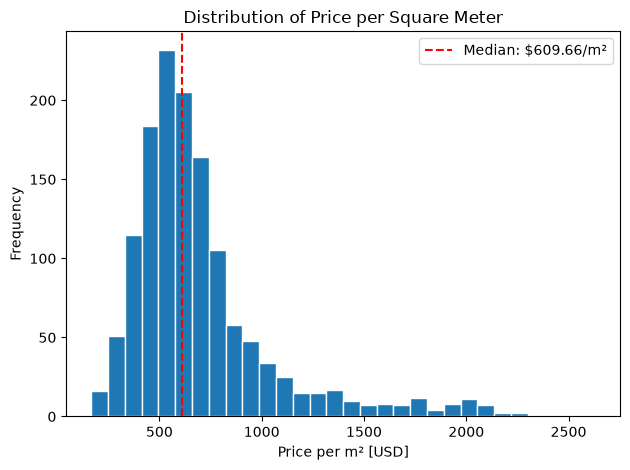

In [23]:
# Create figure and axes
fig, ax = plt.subplots()

# Create histogram with 30 bins
ax.hist(df["price_per_m2"], bins=30, edgecolor="white")

# Set labels and title
ax.set_title("Distribution of Price per Square Meter")
ax.set_xlabel("Price per m² [USD]")
ax.set_ylabel("Frequency")

# Add a vertical line for the median
median_price_per_m2 = df["price_per_m2"].median()
ax.axvline(median_price_per_m2, color='red', linestyle='--', 
           label=f'Median: ${median_price_per_m2:.2f}/m²')
ax.legend()

plt.tight_layout()
plt.show()

> **Reading the `price_per_m2` distribution**
>
> **Shape:** Right-skewed. Most Mexican properties fall in a standard affordability
> range — roughly 300–800/m² — with a long tail of high-value properties
> extending to 2,000/m² and beyond.

## 4. The Location Effect: Grouped Analysis

We hypothesized in Notebook 2 and confirmed visually in Notebook 3 that location
matters. Now we quantify it: how much of the variation in `price_per_m2` is
explained by which state a property is in?

### 4.1 Aggregating by State


In [15]:
# Calculate statistics by state
state_price_stats = (
    df
    .groupby("state")
    ["price_per_m2"]                    # <--- "price_per_m2"
    .agg(['mean', 'median', 'std'])
    .sort_values(by='median', ascending=False)
    
    # Round to 2 decimal places for readability
    .round(2)
)

print("Price per m2 Statistics by State:")
state_price_stats

Price per m2 Statistics by State:


,mean,median,std
state,,,
Distrito Federal,1107.89,955.88,518.28
Quintana Roo,760.02,730.99,269.11
Guerrero,735.03,707.47,236.50
Oaxaca,683.02,683.02,196.87
Estado de México,719.37,671.17,309.71
Campeche,601.29,654.74,157.02
Nayarit,599.29,651.38,196.19
Jalisco,735.39,643.95,339.31
Querétaro,666.48,635.96,192.10


**Reading the state statistics table**

**The top states** (highest median) are typically:
- **Distrito Federal** — Mexico's capital city, where urban density makes land
   extremely scarce. Every m² of space competes with millions of residents and
   businesses.
 - **Coastal or tourist states** — resort areas where international demand
   drives up per-m² prices beyond what local incomes would support.

 **The bottom states** (lowest median) are typically:
 - Rural, agricultural states with low population density, abundant land, and
   limited economic activity.

### 4.2 Visualizing Location Differences

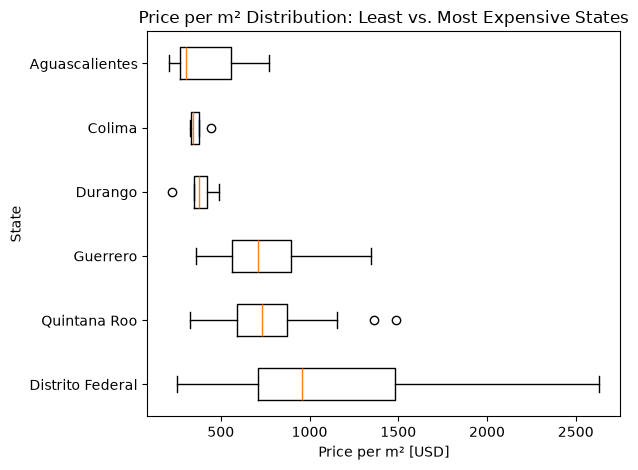

In [25]:
# 1. Identify the states we want to plot (Top 3 and Bottom 3)
top_states = state_price_stats.head(3).index.tolist()
bottom_states = state_price_stats.tail(3).index.tolist()
target_states = top_states + bottom_states

# 2. Filter data by target_states
df_states = df[df["state"].isin(target_states)]

# 3. Prepare data for plotting
# Create a list of arrays, one for each state in our target list
data_to_plot = [df_states[df_states["state"] == state]["price_per_m2"] 
                for state in target_states]

# 4. Plot
fig, ax = plt.subplots()

ax.boxplot(data_to_plot, tick_labels=target_states, orientation='horizontal')
ax.set_title("Price per m² Distribution: Least vs. Most Expensive States")
ax.set_xlabel("Price per m² [USD]")
ax.set_ylabel("State")

plt.tight_layout()
plt.show()

**Reading the top-3 vs bottom-3 states boxplot — the Location Effect**

**Between-group variation (the big story):**
 The gap between the top states (Distrito Federal) and the bottom states is
 enormous. The **median** of Distrito Federal likely exceeds or approaches the
 **maximum** of the least expensive states. This is the Location Effect in its
 purest form: *where* a property sits geographically can matter more than any
 property-specific feature.

**Within-group variation (the nuance):**
 - **Top states (wide boxes):** Expensive states show high within-state inequality.
   In Distrito Federal, a basic apartment and a penthouse can differ by 10× in
   `price_per_m2`. The "average" price in DF masks enormous sub-market variation.
 - **Bottom states (narrow boxes):** Cheaper states tend to have more uniform
   pricing — properties are similarly cheap across the board, with fewer luxury outliers.

### 4.3 Quantifying Location vs Size Effects: Variance Decomposition

Boxplots show the location effect visually. Now let's quantify it: what fraction
of the total variation in `price_per_m2` comes from *between-state* differences vs
*within-state* differences?

In [26]:
analysis_col = "price_per_m2"

# Optional: exclude very small states from the variance decomposition
min_state_n = 10

state_counts = df.groupby("state")[analysis_col].count()
valid_states = state_counts[state_counts >= min_state_n].index

df_var = df[df["state"].isin(valid_states)]

grouped = df_var.groupby("state")[analysis_col]

grand_mean = df_var[analysis_col].mean()

total_ss = ((df_var[analysis_col] - grand_mean) ** 2).sum()

within_ss = (
    grouped
    .apply(lambda s: ((s - s.mean()) ** 2).sum())
    .sum()
)

state_means = grouped.mean()
state_counts_valid = grouped.count()

between_ss = (
    state_counts_valid * (state_means - grand_mean) ** 2
).sum()

between_pct = between_ss / total_ss * 100
within_pct = within_ss / total_ss * 100
ratio_bw = between_ss / within_ss

print(f"Weighted variance decomposition for {analysis_col}")
print(f"States included: {len(state_counts_valid)}")
print(f"Observations used: {len(df_var)}")
print()
print(f"Between-state variation: {between_pct:.1f}%")
print(f"Within-state variation: {within_pct:.1f}%")
print(f"Ratio Between/Within: {ratio_bw:.2f}")

Weighted variance decomposition for price_per_m2
States included: 21
Observations used: 1322

Between-state variation: 29.3%
Within-state variation: 70.7%
Ratio Between/Within: 0.41


**Reading the variance decomposition output**

> Within-state variance > Between-state variance:**
> The market is more uniform across states, and within-state variation (driven
> by size, property type, neighborhood) dominates.
>
> **The ratio (between/within):**
> A ratio > 1.0 means between-state differences explain more than within-state
> differences — location dominates. A ratio < 1.0 means within-state differences
> dominate — other factors matter more.

## 5. The Property Type Effect

Section 4.3 measured how much of the variation in price-per-m² sits *between*
states versus *within* them. Now let's bring in a second grouping variable: does
property *type* also matter? Are apartments "denser" value stores than houses —
even after normalizing for size?

From Notebook 3's reflection on property-type correlations: the area-price
correlation was stronger for houses (r ≈ 0.62) than apartments (r ≈ 0.41),
suggesting that non-size factors matter more for apartments. `price_per_m2`
lets us test this directly.

Price per m² by Property Type:
                  mean  median  count
property_type                        
apartment      1053.69  934.56    333
house           588.87  562.23   1032


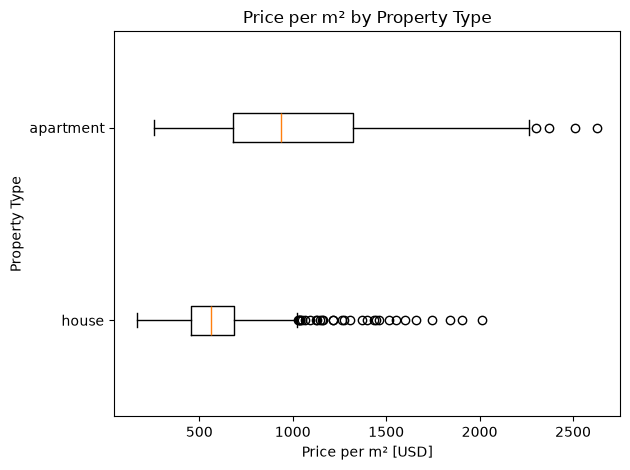

In [27]:
# 1. Calculate summary statistics by property_type
property_type_stats = (
    df
    .groupby("property_type")
    ["price_per_m2"]      #   <--- "price_per_m2"
    .agg(['mean', 'median', 'count'])
    .round(2)
)

print("Price per m² by Property Type:")
print(property_type_stats)

# 2. Get unique property types
prop_types = df["property_type"].unique()

# 3. Prepare data list
data_by_type = [df[df["property_type"] == p_type]["price_per_m2"] 
                for p_type in prop_types]

# 4. Plot
fig, ax = plt.subplots()

ax.boxplot(data_by_type, tick_labels=prop_types, orientation='horizontal')
ax.set_title("Price per m² by Property Type")
ax.set_xlabel("Price per m² [USD]")
ax.set_ylabel("Property Type")

plt.tight_layout()
plt.show()

**Reading the property-type boxplot — apartments vs houses**

**Apartments (typically higher `price_per_m2`):**
- Higher median
- Wider box
  
**Houses (typically lower `price_per_m2`):**
- Lower median 
- Narrow box 
- Right-tail outliers

## 6. Combined Analysis: State and Property Type

Location matters. Property type matters. But how do they *interact*? Is a Distrito
Federal apartment dramatically more expensive per m² than a rural house? Or does
the state effect dominate the property-type effect?

Two-way grouped analysis — state × property type:


In [28]:
# 1. Group by both state and property_type
combined_stats = (
    df
    .groupby(["state", "property_type"])   # <-- "state" and "property_type"
    ["price_per_m2"]      
    .agg(['median', 'count'])
    .round(2)
)

# 2. Filter for groups with at least 20 properties.

combined_stats_filtered = combined_stats[combined_stats['count'] >= 20]

# 3. Sort by median price per m²
combined_stats_filtered = combined_stats_filtered.sort_values(
    by='median', ascending=False
)

print("Top 15 State-Property Type Combinations:")
display(combined_stats_filtered.head(15))

print("\nBottom 10 State-Property Type Combinations:")
combined_stats_filtered.tail(10)

Top 15 State-Property Type Combinations:


,,median,count
state,property_type,,
Distrito Federal,apartment,1100.12,170
Puebla,apartment,960.88,22
Yucatán,apartment,792.38,20
Guerrero,apartment,738.41,24
Distrito Federal,house,724.43,58
Estado de México,house,654.67,108
Quintana Roo,house,632.24,21
Querétaro,house,628.18,88
Jalisco,house,614.91,38



Bottom 10 State-Property Type Combinations:


,,median,count
state,property_type,,
Morelos,house,612.00,113
Puebla,house,574.16,55
Baja California,house,572.56,22
Chiapas,house,567.04,42
Tamaulipas,house,557.98,38
Nuevo León,house,492.62,49
San Luis Potosí,house,487.35,41
Veracruz de Ignacio de la Llave,house,483.07,91
Yucatán,house,474.52,124


## 7. Final Conclusion: Size vs. Location

We have analyzed the data from four angles across this project:

1. **Distributions (Notebooks 1-2):** Prices are right-skewed — most properties are
   modestly priced, but luxury properties at the high end inflate the mean
   substantially above the median.

2. **Scatterplots and outliers (Notebook 2):** There is a positive relationship between
   size and price, but with significant scatter — size alone leaves much of the
   price variation unexplained.

3. **Correlations (Notebook 3):** The national area-price correlation is r ≈ 0.46 —
   moderate — but this average conceals enormous state-level variation
   (from r ≈ 0.0 to r ≈ 0.9+). This is a demonstration of Simpson's Paradox:
   aggregate statistics can hide contradictory subgroup behavior.

4. **Grouped analysis (Notebook 4):** The variance decomposition (section 4.3, run on
   `price_per_m2`) split total price-per-m² variation into a between-state share
   and a within-state share:
   between = **29.3%**, within = **70.7%**, ratio = **0.41**.

## **Answer to the Research Question**

The variance decomposition on `price_per_m2` showed between-state variance at
29.3%, within-state variance at 70.7% (ratio ≈ 0.41) — within-state variance is
larger. State-level differences are real: Distrito Federal is systematically
pricier than Colima, for example. But most of the total variation in
`price_per_m2` happens *between individual properties within the same state*,
not between states. That points to unmeasured, property-level factors —
condition, exact neighborhood, floor, amenities, building age — explaining more
of the price-per-m² story than either size or state alone.

Size still matters: the national area-price correlation was r ≈ 0.46
(Notebook 3), and higher still within some individual states. That's real
evidence size isn't irrelevant — it's just not the *dominant* factor once price
is measured per square meter.

**In short: both location and size correlate with price, but neither one
dominates. Most of the variation in price per square meter comes from factors
this dataset doesn't capture.**

This dataset has no neighborhood-, condition-, or amenity-level features, so
"within-state variance" is really a stand-in for everything the data doesn't
measure."